# Final Project DS4420 - Eric Gerber 
Alina Gonzalez, Veronica Song, Sophia Yang 

Clean up and compile datasets from PetFinder dataset to match breed_id to breed, etc

Build out a CNN to identify key traits from animal given picture of pet
Build out MLP to predict adoption speed/ likelihood based off traits

In [23]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

In [ ]:
# imports for cnn
import keras
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Dense, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten
from keras.optimizers import SGD
from keras.losses import binary_crossentropy

In [25]:
# data is organized kinda weirdly, train.csv has all the columns in one but gotta link breed_id to actual breed name
petfinder = pd.read_csv("petfinder-adoption-prediction_data/train/train.csv").set_index("PetID")

petfinder.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PhotoAmt,AdoptionSpeed
PetID,,,,,,,,,,,,,,,,,,,,,
86e1089a3,2,Nibble,3,299,0,1,1,7,0,1,...,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,1.0,2
6296e909a,2,No Name Yet,1,265,0,1,1,2,0,2,...,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,2.0,0
3422e4906,1,Brisco,1,307,0,1,2,7,0,2,...,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,7.0,3
5842f1ff5,1,Miko,4,307,0,2,1,2,0,2,...,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",8.0,2
850a43f90,1,Hunter,1,307,0,1,1,0,0,2,...,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,3.0,2


# Building the MLP -- wait lowkey ignore this section it doesn't work anyway

Using visual variables of each pet like breed, color, and furlength to predict adoption speed. 
Will eventually need to feed in identified visual variables from CNN to MLP to predict adoption speed

In [60]:
# separating out y and x values
# trying to predict adoption speed
y = petfinder["AdoptionSpeed"]
y = y.to_numpy()

# extract visual variables used to build MLP
char = ["Breed1", "Breed2", "Color1", "Color2", "Color3"]
pet_char = petfinder[char]
X = pet_char

# Scaling with min-max scaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X).round(2)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train

array([[0.87, 0.  , 0.  , 0.57, 1.  ],
       [1.  , 0.  , 0.  , 1.  , 0.  ],
       [1.  , 0.  , 0.  , 0.  , 0.  ],
       ...,
       [0.87, 0.  , 1.  , 0.  , 0.  ],
       [0.87, 0.  , 0.  , 0.57, 0.71],
       [0.87, 0.  , 0.  , 1.  , 0.  ]])

In [62]:
eta = .001 # this is my n value
epochs = 500
q = 128 # number of hidden nodes for W1
q2 = 64 # number of hidden nodes for W2
q3 = 32 # number of hidden nodes for W3
n, d = X.shape

# defining bias terms
b1 = np.zeros((q,1))
b2 = np.zeros((q2,1))
b3 = np.zeros((q3,1))
b4 = np.zeros((1, 1))

# Random initialization of initial weights
# using He initialization and smaller weights or else everything blows up
W1 = np.random.randn(d, q) * np.sqrt(2/d) * 0.5
W2 = np.random.randn(q, q2) * np.sqrt(2/q) * 0.5 
W3 = np.random.randn(q2, q3) * np.sqrt(2/q2) * 0.5
W4 = np.random.randn(q3, 1) * np.sqrt(2/q3) * 0.5

# defining relu function
def relu(x):
    return np.maximum(0, x)
    
# defining the regression function
def f(x):
    h = relu(W1.T.dot(x) + b1)
    h2 = relu(W2.T.dot(h) + b2)
    h3 = relu(W3.T.dot(h2) + b3)
    return (W4.T.dot(h3) + b4)

# defining derivative of relu
def relu_deriv(x):
    return (x > 0).astype(float)

In [65]:
errors = []

n = X_train.shape[0]   # number of training samples

for epoch in range(epochs): # run the training loop
    dW1 = np.zeros_like(W1)
    dW2 = np.zeros_like(W2)
    dW3 = np.zeros_like(W3)
    dW4 = np.zeros_like(W4)
    
    db1 = np.zeros_like(b1)
    db2 = np.zeros_like(b2)
    db3 = np.zeros_like(b3)
    db4 = np.zeros_like(b4)

    # loop through one full pass (forward + backward)
    for i, j in enumerate(y_train):
        x = X_train[i].reshape(d, 1)  
        y_true = y_train[i]
        Y = np.array([[y_true]])     
        
        # forward pass
        z1 = W1.T @ x + b1
        h1 = relu(z1)
        
        z2 = W2.T @ h1 + b2
        h2 = relu(z2)
        
        z3 = W3.T @ h2 + b3
        h3 = relu(z3)
        
        z4 = W4.T @ h3 + b4
        y_hat = z4 

        # # calculate loss
        # loss = (y_hat - Y)**2
        
        # backward pass
        dz4 = 2 * (y_hat - Y)                 
        dW4 += h3 @ dz4.T         
        db4 += dz4
        
        dh3 = W4 @ dz4
        dz3 = dh3 * relu_deriv(z3)
        
        dW3 += h2 @ dz3.T
        db3 += dz3
        
        dh2 = W3 @ dz3
        dz2 = dh2 * relu_deriv(z2)
        
        dW2 += h1 @ dz2.T
        db2 += dz2
        
        dh1 = W2 @ dz2
        dz1 = dh1 * relu_deriv(z1)
        
        dW1 += x @ dz1.T              
        db1 += dz1
        
    # Update weights and bias terms
    W1 -= eta * dW1
    b1 -= eta * db1
    
    W2 -= eta * dW2
    b2 -= eta * db2
    
    W3 -= eta * dW3
    b3 -= eta * db3
    
    W4 -= eta * dW4
    b4 -= eta * db4

    # if epoch % 50 == 0:
    #     print(f"Epoch {epoch}, Loss: {loss}")
        
    # compute loss on training set (given regression function)
    preds = []
    for i in range(n):
        x = X_train[i].reshape(d,1)
        preds.append(f(x))
    
    preds = np.array(preds).flatten()
    loss = np.mean((preds - y_train)**2)

# predictions on training set
predicted = f(X_train.T)
print(predicted)

[[nan nan nan ... nan nan nan]]


In [60]:
n_test = X_test.shape[0]

predicted_test = np.array([
    f(np.reshape(X_test[i], (d, 1))) for i in range(n_test)
]).flatten()

predicted_labels = (predicted_test >= 0.5).astype(int)
accuracy = np.mean(predicted_labels == y_test)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.1971987550022232


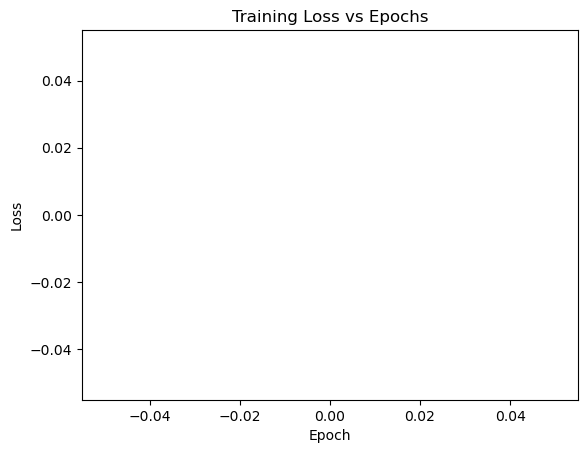

In [62]:
# Evaluating algorithm accuracy
plt.plot(range(len(errors)), errors)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.show()

# Building the CNN

In [79]:
""" 
Image data cleanup

Dataset provided images of animals and separate folder of jsons on description metadata
Match images of animals to their relevant metadata on dog breed(s) and color(s)

"""
# open the metadata and images provided by the dataset
TRAIN_METADATA_PATH = "petfinder-adoption-prediction_data/train_metadata"
TEST_METADATA_PATH = "petfinder-adoption-prediction_data/test_metadata"
TRAIN_IMAGES_PATH = "petfinder-adoption-prediction_data/train_images"
TEST_IMAGES_PATH = "petfinder-adoption-prediction_data/test_images"

# data set up is folder of images with ID in jpg name that corresponds to metadata json name in a folder of metadata..
# metadata json is weird too with multiple descriptions either saying "dog/ cat" or giving the actual breed
def extract_animal_type(labels):
    """
    from json metadata pull out if the animal iamge is a dog/ cat
    """
    descriptions = [l["description"].lower() for l in labels]
    if "dog" in descriptions:
        return 1
    elif "cat" in descriptions:
        return 0
    return None

# Need to extract breeds (1 and 2) from metadata too
# labels for breeds stored in two diff csv files

breeds = pd.read_csv("petfinder-adoption-prediction_data/breed_labels.csv")["BreedName"]
more_breeds = pd.read_csv("petfinder-adoption-prediction_data/BreedLabels.csv")["BreedName"]

# join the two dfs
breeds = pd.concat([breeds, more_breeds], ignore_index=True)

def extract_breeds(labels):
    """
    from json metadata pull out 2 breeds mentioned in the description
    """
    breeds = []
    for l in labels:
        desc = l["description"].lower()
        if desc in breeds:
            breeds.append(desc)
    return breeds[:2] 

# Need to extract colors from metadata json too
# colors are formatted like
#                 dominantColors: {     
#                     "color": {
#                         "red": 186,
#                         "green": 201,
#                         "blue": 229
#                     } with multiple "color" categories I fear and scores with each
# I think is giving RGB breakdown of the color identified and then score is amount of that color seen in the image
def extract_colors(color_data, top_k=3):
    """
    from json metadata pull out top colors of the animal based on scores provided
    """
    colors = sorted(color_data, key=lambda x: x["score"], reverse=True)
    top_colors = colors[:top_k]
    
    return [(c["color"]["red"], c["color"]["green"], c["color"]["blue"])
            for c in top_colors]

In [83]:
# running the functions to extract animal type, breed(s), and colors
import os
import json
from PIL import Image

def load_data(IMAGES_PATH, METADATA_PATH):
    """
    Open the image and metadata paths and load the data
    """
    data = []

    image_files = [f for f in os.listdir(IMAGES_PATH) if f.endswith(".jpg")]

    for img_file in image_files:
        # find each unique ID for each pet to connect to its corresponding metadata file
        file_id = img_file.replace(".jpg", "")
        
        img_path = os.path.join(IMAGES_PATH, img_file)
        meta_path = os.path.join(METADATA_PATH, file_id + ".json")

        if not os.path.exists(meta_path):
            continue

        # load image in color
        image = Image.open(img_path).convert("RGB")

        # load metadata
        with open(meta_path) as f:
            meta = json.load(f)

        data.append((image, meta))

    return data

In [85]:
def process_sample(image, meta):
    """
    from each file, extract the key visual components of the pet (breed(s) and colors)
    """
    labels = meta["labelAnnotations"]
    colors = meta["imagePropertiesAnnotation"]["dominantColors"]["colors"]

    animal = extract_animal_type(labels)
    breeds = extract_breeds(labels)
    color_vals = extract_colors(colors)

    return image, animal, breeds, color_vals

In [ ]:
%pip install torch

In [87]:
# use torchvision to transform the images
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def prepare_batch(data_batch):
    """
    separate out images, animal type, breeds, and colors into separate lists for batching
    """
    images, animals, breeds, colors = [], [], [], []

    for img, meta in data_batch:
        img, animal, breed, color = process_sample(img, meta)

        images.append(transform(img))
        animals.append(animal)
        breeds.append(breed)
        colors.append(color)

    return images, animals, breeds, colors

def create_batches(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i:i+batch_size]

ModuleNotFoundError: No module named 'torchvision'

## THIS IS WHERE HISTORIC HOMEWORK CODE STARTS THAT I WAS TRYING TO REFERENCE

In [ ]:
# setting all images to same img size
from PIL import Image, ImageOps

def convert_image_to_scale_with_padding(image_path, target_width, target_height):
    """
    Converts a single .jpg image to the target dimensions.

    Args:
        image_path (str): Path to the input .jpg image.
        target_width (int, optional): Target width for padding
        target_height (int, optional): Target height for padding

    Returns:
        np.ndarray: image as a numpy array, with padding applied.
    """
    # Open the image
    with Image.open(image_path) as img:
        # If target dimensions are provided, pad the image
        if target_width and target_height:
            padded_img = ImageOps.pad(img, (target_width, target_height), color=0)
        else:
            print("Need to provide target width and height")

        # Convert the image to a numpy array
        array = np.array(padded_img)

    return array

In [ ]:
img_rows, img_cols = 540, 499

# define the input with the image rows, cols, and grayscale column
inpx = Input(shape=(img_rows, img_cols, 1))

# define convolutional layer 1
con_layer = Conv2D(1, padding = 'same', kernel_size=(4, 4), strides=1, activation=None)(inpx)
con_layer = MaxPooling2D((2,2))(con_layer)
# define convolutional layer 2
con_layer2 = Conv2D(1, kernel_size=(3, 3), strides=1, activation=None)(con_layer)

# flattening the image
flat_G = Flatten()(con_layer2)

# establishing hidden layers
# hidden layer 1
hid_layer = Dense(64, activation='relu')(flat_G)
# hidden layer 2
hid_layer2 = Dense(32, activation='relu')(hid_layer)

# defining output function (5 outputs for 5 traits of pet we want to identify)
out_layer = Dense(5, activation='sigmoid')(hid_layer2)

# fitting the model
model = Model([inpx], out_layer)

model.compile(optimizer="adam",
              loss=binary_crossentropy,
              metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs=10)

In [ ]:
# calculate the accuracy score
score = model.evaluate(x_test, y_test, verbose=0)
print('loss=', score[0])
print('accuracy=', score[1])